In [1]:
import gdown
import torch

from kolmogorov_flow_matching import (
    ConditionalDiffusion,
    ConditionalFlowMatching,
    ConditionalUnetBackbone,
    TimeseriesDataset,
    benchmark_integration_methods,
    download_valid_set,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
diffusion_file_id = "1CAsyFcUCq8x0B0F6jSNseZu6GW1jueJQ"
diffusion_output = "../checkpoints/diffusion.pt"
gdown.download(id=diffusion_file_id, output=diffusion_output, quiet=False)

flow_matching_file_id = "19udeScHOnfsutrA7jGT2L2Zp6Rqor2oK"
flow_matching_output = "../checkpoints/flow_matching.pt"
gdown.download(id=flow_matching_file_id, output=flow_matching_output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1CAsyFcUCq8x0B0F6jSNseZu6GW1jueJQ
To: /home/user3/dev/Kolmogorov-Flow-Matching/checkpoints/diffusion.pt
100%|██████████| 24.8M/24.8M [00:00<00:00, 52.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=19udeScHOnfsutrA7jGT2L2Zp6Rqor2oK
To: /home/user3/dev/Kolmogorov-Flow-Matching/checkpoints/flow_matching.pt
100%|██████████| 24.8M/24.8M [00:00<00:00, 52.6MB/s]


'../checkpoints/flow_matching.pt'

In [3]:
diff_path = "../checkpoints/diffusion.pt"
fm_path = "../checkpoints/flow_matching.pt"

diff_state_dict = torch.load(diff_path, map_location=device)
diff_model = ConditionalDiffusion(ConditionalUnetBackbone()).to(device)
diff_model.load_state_dict(diff_state_dict["model_state_dict"])

fm_state_dict = torch.load(fm_path, map_location=device)
fm_model = ConditionalFlowMatching(ConditionalUnetBackbone()).to(device)
fm_model.load_state_dict(fm_state_dict["model_state_dict"])

<All keys matched successfully>

In [4]:
k_frames = 4  # Number of history frames to condition on
target_steps = 10  # Number of future steps to predict

print("Downloading/Locating datasets...")
valid_h5_path = download_valid_set("../data/valid")

valid_set = TimeseriesDataset(
    h5_file_path=valid_h5_path,
    k_frames=k_frames,
    target_steps=target_steps,
    dataset_key="valid/u",
)

Downloading/Locating datasets...
Computing global statistics for ../data/valid/valid/KolmFlow_valid_256.h5...
Done! Mean: 0.00000, Std: 3.50252


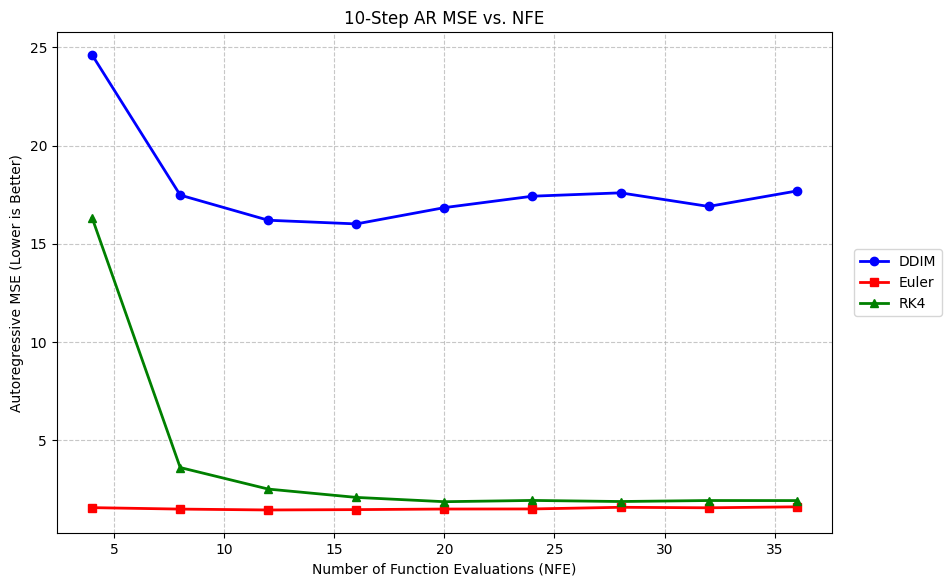

Evaluating NFEs: 100%|██████████| 9/9 [00:41<00:00,  4.59s/it]


In [5]:
benchmark_integration_methods(valid_set, diff_model, fm_model, device=device)